# PID-Controlled Spring-Mass-Damper System

Control the position of a mass on a spring-damper using a **PID controller**.

- **Plant**: $m\ddot{x} + b\dot{x} + kx = u$
- **Control**: $u = K_p e + K_d \dot{e} + K_i \int\!e\,dt$,  where $e = r - x$
- **Goal**: track a step reference $r$ with minimal overshoot and fast settling

In [12]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

print("Libraries loaded.")

Libraries loaded.


## 1. System Model

$$
m\ddot{x} + b\dot{x} + kx = u
$$

where $u$ is the control force.  We convert to first-order form with an integrator state for the PID:

$$
\begin{cases}
\dot{x} = v \\
\dot{v} = \dfrac{1}{m}(-b v - k x + u) \\
\dot{z} = e = r - x \\
u = K_p (r - x) + K_d (0 - v) + K_i z
\end{cases}
$$

In [13]:
m = 1.0
b = 0.5
k = 2.0

Kp = 20.0
Kd = 4.0
Ki = 2.0

r = 1.0

def smd_pid_ode(t, y):
    x, v, z = y
    e = r - x
    u = Kp * e + Kd * (0 - v) + Ki * z
    dx = v
    dv = (-b * v - k * x + u) / m
    dz = e
    return [dx, dv, dz]

## 2. Simulate Step Response

Start from rest at $x=0$; the PID should drive $x \to r = 1$.

In [14]:
x0, v0, z0 = 0.0, 0.0, 0.0
t_span = (0, 15)
t_eval = np.linspace(0, 15, 500)

sol = solve_ivp(
    smd_pid_ode, t_span, [x0, v0, z0],
    t_eval=t_eval, method='RK45', rtol=1e-8
)

x_pid = sol.y[0]
v_pid = sol.y[1]
e_hist = r - x_pid
u_hist = Kp * e_hist + Kd * (0 - v_pid) + Ki * sol.y[2]

print(f"Simulated {len(sol.t)} time steps.")

Simulated 500 time steps.


## 3. Compare: Open-Loop vs PID-Controlled

The open-loop response (no control force) does not settle; the PID drives $x \to r$ quickly.

<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9215/2768223992.py:23: SyntaxWarning: invalid escape sequence '\d'
  ax1.plot(t_eval, v_pid, color='C1', label="Velocity $\dot{x}$", lw=1)


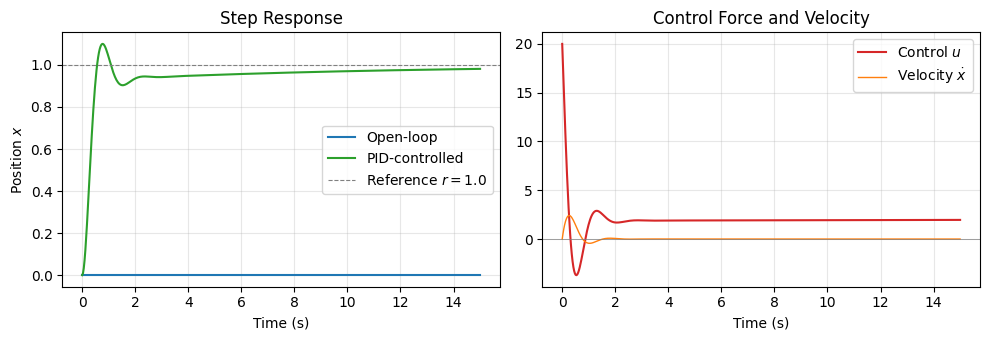

Rise time to 98%: 14.31 s
Steady-state error: 0.0187


In [15]:
def simulate_open_loop():
    def ode(t, y):
        x, v = y
        return [v, (-b * v - k * x) / m]
    sol_ol = solve_ivp(ode, t_span, [x0, v0],
                       t_eval=t_eval, method='RK45', rtol=1e-8)
    return sol_ol.y[0]

x_ol = simulate_open_loop()

fig0, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5))

ax0.plot(t_eval, x_ol, color='C0', label="Open-loop")
ax0.plot(t_eval, x_pid, color='C2', label="PID-controlled")
ax0.axhline(r, color='gray', ls='--', lw=0.8, label=f"Reference $r={r}$")
ax0.set_xlabel("Time (s)")
ax0.set_ylabel("Position $x$")
ax0.set_title("Step Response")
ax0.legend()
ax0.grid(True, alpha=0.3)

ax1.plot(t_eval, u_hist, color='C3', label="Control $u$")
ax1.plot(t_eval, v_pid, color='C1', label="Velocity $\dot{x}$", lw=1)
ax1.set_xlabel("Time (s)")
ax1.set_title("Control Force and Velocity")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.show()

idx_98 = np.searchsorted(x_pid, 0.98 * r)
t_rise = t_eval[idx_98] if idx_98 < len(t_eval) else None
print(f"Rise time to 98%: {t_rise:.2f} s")
print(f"Steady-state error: {abs(x_pid[-1] - r):.4f}")

## 4. Effect of PID Gains

Compare step responses for different tuning values.

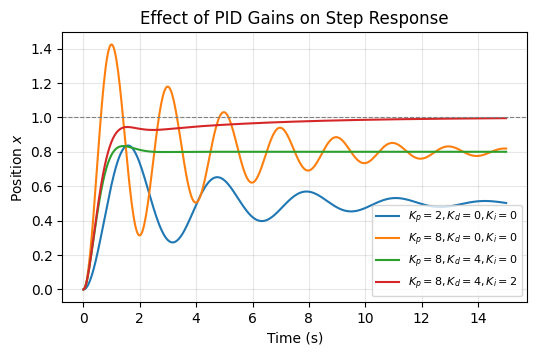

In [16]:
tunings = [
    ("$K_p=2, K_d=0, K_i=0$", 2, 0, 0, 'C0'),
    ("$K_p=8, K_d=0, K_i=0$", 8, 0, 0, 'C1'),
    ("$K_p=8, K_d=4, K_i=0$", 8, 4, 0, 'C2'),
    ("$K_p=8, K_d=4, K_i=2$", 8, 4, 2, 'C3'),
]

fig_g, ax_g = plt.subplots(figsize=(6, 3.5))

for label, kp, kd, ki, color in tunings:
    def ode(t, y):
        x, v, z = y
        e = r - x
        u = kp * e + kd * (0 - v) + ki * z
        return [v, (-b * v - k * x + u) / m, e]
    sol_g = solve_ivp(ode, t_span, [0, 0, 0],
                      t_eval=t_eval, method='RK45', rtol=1e-8)
    ax_g.plot(t_eval, sol_g.y[0], color=color, label=label)

ax_g.axhline(r, color='gray', ls='--', lw=0.8)
ax_g.set_xlabel("Time (s)")
ax_g.set_ylabel("Position $x$")
ax_g.set_title("Effect of PID Gains on Step Response")
ax_g.legend(fontsize=8)
ax_g.grid(True, alpha=0.3)
plt.show()

## 5. Animate the Mass-Spring-Damper

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 5))
gs = GridSpec(3, 4, figure=fig)
ax_anim = fig.add_subplot(gs[:, 0])
ax_pos = fig.add_subplot(gs[0, 1:])
ax_vel = fig.add_subplot(gs[1, 1:])
ax_ctrl = fig.add_subplot(gs[2, 1:])

ax_anim.set_xlim(-0.3, 2.0)
ax_anim.set_ylim(-0.5, 0.5)
ax_anim.set_aspect('equal')
ax_anim.set_title(f"")
ax_anim.axis('off')

wall, = ax_anim.plot([-0.1, -0.1], [-0.3, 0.3], color='gray', lw=4)
spring_line, = ax_anim.plot([], [], color='C0', lw=1.5)
mass, = ax_anim.plot([], [], 's', color='C2', markersize=20, zorder=5)
damper_line, = ax_anim.plot([], [], color='gray', lw=1.5, ls='--')
ax_anim.axvline(r, color='gray', ls='--', lw=0.8, alpha=0.6)

ax_pos.set_xlim(t_span[0], t_span[1])
ax_pos.set_ylim(-0.3, 1.3 * r)
ax_pos.set_ylabel("Position $x$")
ax_pos.set_title("System Response")
ax_pos.grid(True, alpha=0.3)
pos_line, = ax_pos.plot([], [], color='C2', lw=1.5)
pos_ref = ax_pos.axhline(r, color='gray', ls='--', lw=0.8, alpha=0.6)

ax_vel.set_xlim(t_span[0], t_span[1])
ax_vel.set_ylim(-1.5, 1.5)
ax_vel.set_ylabel("Velocity $\\dot{x}$")
ax_vel.grid(True, alpha=0.3)
vel_line, = ax_vel.plot([], [], color='C1', lw=1.5)
ax_vel.axhline(0, color='gray', lw=0.5)

ax_ctrl.set_xlim(t_span[0], t_span[1])
ax_ctrl.set_ylim(-4, 10)
ax_ctrl.set_xlabel("Time (s)")
ax_ctrl.set_ylabel("Control $u$")
ax_ctrl.grid(True, alpha=0.3)
ctrl_line, = ax_ctrl.plot([], [], color='C3', lw=1.5)
ax_ctrl.axhline(0, color='gray', lw=0.5)

plt.tight_layout()

def init():
    spring_line.set_data([], [])
    mass.set_data([], [])
    damper_line.set_data([], [])
    pos_line.set_data([], [])
    vel_line.set_data([], [])
    ctrl_line.set_data([], [])
    return spring_line, mass, damper_line, pos_line, vel_line, ctrl_line

def animate(i):
    xi = x_pid[i]
    spring_line.set_data([0, xi], [0, 0])
    mass.set_data([xi], [0])
    damper_line.set_data([xi, xi], [-0.2, 0.2])
    pos_line.set_data(t_eval[:i], x_pid[:i])
    vel_line.set_data(t_eval[:i], v_pid[:i])
    ctrl_line.set_data(t_eval[:i], u_hist[:i])
    return spring_line, mass, damper_line, pos_line, vel_line, ctrl_line

ani = FuncAnimation(fig, animate, frames=len(t_eval),
                    init_func=init, blit=True, interval=30)

plt.close(fig)
HTML(ani.to_jshtml())

## 6. Phase Portrait

Trajectory in the $x$-$\dot{x}$ plane.

In [ ]:
fig2, ax2 = plt.subplots(figsize=(5, 4))
ax2.plot(x_pid, v_pid, color='C2')
ax2.plot(x_pid[0], v_pid[0], 'o', color='C2', label="Start")
ax2.plot(x_pid[-1], v_pid[-1], 's', color='C2', label="End")
ax2.set_xlabel("Position $x$")
ax2.set_ylabel("Velocity $\dot{x}$")
ax2.set_title("Phase Portrait")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', lw=0.5)
ax2.axvline(r, color='gray', ls='--', lw=0.5)
plt.show()